In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Data about Formula 1 Races (1950-2024): https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020/data.
Contains information about every driver in every season for each individual race. Includes lap times, pit stops, position, and more. Note: some data only goes back to 2011, and the points systems have changed over time. 

Questions:
1. How have the average number of pit stops per race changed between 2011 and 2024?
2. How does starting grid position correlate to driver points earned between 2011 and 2024?
3. Who have been the 3 most successful drivers for McLaren F1 (most points earned for McLaren)?

Question 1 approach:
1. Cut unnecesary data, we only need raceId, driverId, and stop.
2. First get rid of extra pit stops. The data set has each pit stop in a race for each driver rather than the count,
   so by eliminating all pit stops other than their last, we get the count instead. (Rename column to "stop count")
3. Use raceId to find the year of the race. Create a new column for year.
4. Get rid of raceId and driverId. We only needed them to isolate pit stop count and year.
5. Plot data with line to see the change over time.

Step 1

In [266]:
#get data and filter columns
pit_stops = pd.read_csv("pit_stops.csv")
pit_stops = pit_stops[['raceId', 'driverId', 'stop']]
pit_stops.head()

,raceId,driverId,stop
0,841,153,1
1,841,30,1
2,841,17,1
3,841,4,1
4,841,13,1


Step 2 (The script below takes 20 minutes to run, so its output was saved to "calculated_pit_stops.csv" and that is used instead)

In [267]:
%%script false
"""
Since the data has each individual pit stop rather than the number
of pit stops per driver per race, we filter all the stops to only 
include the highest number stop for each driver in each race, which
is the number of stops they made. 
"""

i = 0

#go through each pit stop
while i < pit_stops['stop'].size:

        highestIndex = i;
    
        #go through the rest of the pit stops and eliminate all other duplicates with lower stop numbers
        j = highestIndex + 1;
        while j < pit_stops['stop'].size:

            #check for match
            if pit_stops['raceId'].iloc[highestIndex] == pit_stops['raceId'].iloc[j] and \
            pit_stops['driverId'].iloc[highestIndex] == pit_stops['driverId'].iloc[j]:

                #matching stop found
                if pit_stops['stop'].iloc[j] > pit_stops['stop'].iloc[highestIndex]:
                    #found a new highest, replace the highest

                    if highestIndex == i:
                        #account for index change in outer loop
                        i -= 1
                    
                    #drop former highest 
                    pit_stops.drop(pit_stops.index[highestIndex], inplace = True)

                    #set new highest
                    highestIndex = j;

                    #account for index change in inner loop
                    #j -= 1
                    
                else:
                    #found a lower value, drop this value
                    #drop current value 
                    pit_stops.drop(pit_stops.index[j], inplace = True)

                    #account for index change in inner loop
                    j -= 1     

            j += 1

        i += 1
        print("Finished:", i, " new size:", pit_stops['stop'].size)

Couldn't find program: 'false'


In [268]:
#reads already processed data to save time
pit_stops = pd.read_csv("calculated_pit_stops.csv")

Steps 3 & 4

In [269]:
#load race data
races = pd.read_csv("races.csv")

#map years to raceId using race data
pit_stops['raceId'] = pit_stops['raceId'].map(races.set_index('raceId')['year'])

#rename column to year and get rid of driverId
pit_stops = pit_stops[['raceId', 'stop']]
pit_stops.rename(columns={'raceId': 'year', 'stop': 'stops'}, inplace=True)

pit_stops.head()

,year,stops
0,2011,1
1,2011,1
2,2011,2
3,2011,1
4,2011,1


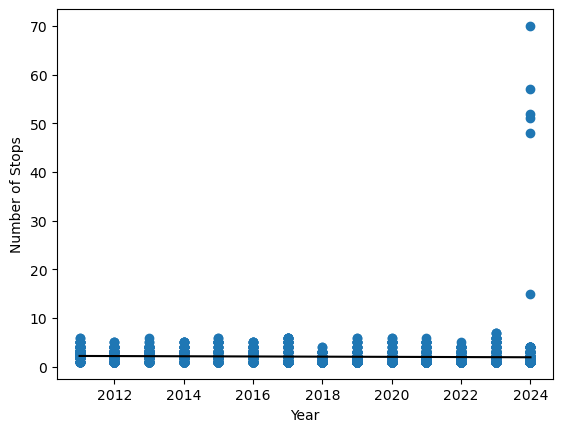

Model score: 0.0
Model equation: y = -0.02 x + 43.44


In [270]:
#plot values and run linear regression model to find rate of change
x = pit_stops['year'].values
y = pit_stops['stops'].values
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

#create model
model = LinearRegression().fit(x, y)

#create figure
plt.figure()
plt.scatter(x, y)
plt.xlabel("Year")
plt.ylabel("Number of Stops")
plt.plot([2011, 2024], [model.intercept_[0] + 2011 * model.coef_[0][0], model.intercept_[0] + 2024 * model.coef_[0][0]], 'k-')
plt.show()

#output information
print("Model score:", round(model.score(x, y), 2))
print("Model equation: y =", round(model.coef_[0][0], 2), "x +", round(model.intercept_[0], 2))

Question 1 answer: Essentially, no, the number of pit stops on average has not changed. In fact, the model is so horizontal that the score is 0. 

Question 2 approach:
1. Cut unnecessary data, we only want grid and points.
2. Filter for all race id's greater than or equal to 841 (2011).
3. Cut drivers at position 0 or results with more than 26 points (these are invalid).
4. Plot the data and run linear regression. Print model score and equation. 

Step 1

In [271]:
#read results data
results = pd.read_csv("results.csv")
results = results[['raceId', 'grid', 'points']]
results.head()

,raceId,grid,points
0,18,1,10.0
1,18,5,8.0
2,18,7,6.0
3,18,11,5.0
4,18,3,4.0


Step 2

In [272]:
#filter results by year (841 is the first race in 2011)
results = results[results['raceId'] >= 841]

#cut unnecessary columns
results = results[['grid', 'points']]
results.head()

,grid,points
20776,1,25.0
20777,2,18.0
20778,6,15.0
20779,5,12.0
20780,3,10.0


Step 3

In [273]:
#cut any results that aren't possible
results = results[results['grid'] >= 1]
results = results[results['points'] <= 26]

Step 4

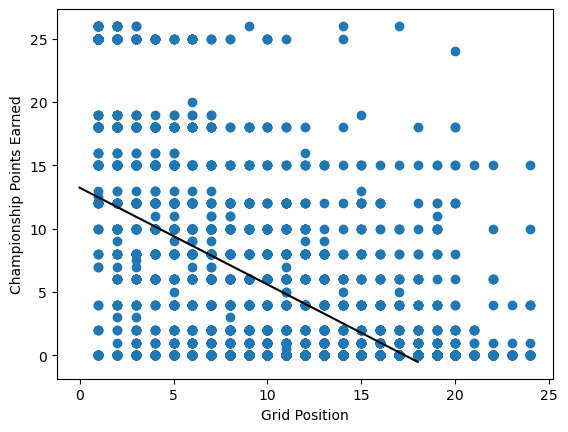

Model score: 0.42
Model equation: y = -0.76 x + 13.23


In [274]:
#plot data and create linear model
x = results['grid'].values
y = results['points'].values
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

#generate linear model
model = LinearRegression().fit(x, y)

#plot data
plt.figure()
plt.scatter(x, y)
plt.xlabel("Grid Position")
plt.ylabel("Championship Points Earned")
plt.plot([0, 18], [model.intercept_[0], model.intercept_[0] + 18 * model.coef_[0][0]], 'k-')
plt.show()

#print r^2 and equation
print("Model score:", round(model.score(x, y), 2))
print("Model equation: y =", round(model.coef_[0][0], 2), "x +", round(model.intercept_[0], 2))

Question 2 answer:
Grid starting position is negatively correlated with points earned. On average, a driver starting on pole position earns around 12 points, and after than, drivers are less and less likely to earn points. However, the model score is a low 0.42, so all kinds of random results can be expected. Each position further down the grid, expected points lowers by 0.76, until it reaches 0 at around 18th position. 

Question 3 approach:
1. Filter results dataset to only include McLaren results.
2. Cut data to only be driverId and positionOrder. Since the points system has changed over time, all races will be remapped to the new points system to figure out which driver contributed the most to the team, the fastest lap point is ommitted since it is not very impactful.
3. Switch driverId for driver name.
4. Map the position order to a number of points.
5. Add up the number of points for each driver.
6. Find which 3 drivers earned the most points.

Steps 1 & 2

In [275]:
#releoad results data
resultsMcLaren = pd.read_csv("results.csv")

#cut to only include McLaren data (constructorId 1)
resultsMcLaren = resultsMcLaren[resultsMcLaren['constructorId'] == 1]

resultsMcLaren = resultsMcLaren[['driverId', 'positionOrder']]
resultsMcLaren.head()

,driverId,positionOrder
0,1,1
4,5,5
24,5,3
26,1,5
48,5,5


Step 3

In [276]:
#get driver data for driver names
drivers = pd.read_csv("drivers.csv")

#map driver id to driver name
resultsMcLaren['driverId'] = resultsMcLaren['driverId'].map(drivers.set_index('driverId')['driverRef'])

#rename columns
resultsMcLaren.rename(columns={'driverId': 'driver', 'positionOrder': 'position'}, inplace=True)

resultsMcLaren.head()

,driver,position
0,hamilton,1
4,kovalainen,5
24,kovalainen,3
26,hamilton,5
48,kovalainen,5


Step 4

In [277]:
#create a dataframe to relate position to points
positionPoints = [
    [1, 25],
    [2, 18],
    [3, 15],
    [4, 12],
    [5, 10], 
    [6, 8],
    [7, 6],
    [8, 4],
    [9, 2],
    [10, 1],
    [11, 0],
    [12, 0],
    [13, 0],
    [14, 0],
    [15, 0],
    [16, 0],
    [17, 0],
    [18, 0],
    [19, 0],
    [20, 0],
    [21, 0],
    [22, 0],
    [23, 0],
    [24, 0],
    [25, 0],
    [26, 0],
    [27, 0],
    [28, 0]
]

positionPointsData = pd.DataFrame(positionPoints, columns=['position', 'points'])

#use the dataframe to map position to effective points
resultsMcLaren['position'] = resultsMcLaren['position'].map(positionPointsData.set_index('position')['points'])

#rename columns
resultsMcLaren.rename(columns={'driver': 'driver', 'position': 'points'}, inplace=True)

resultsMcLaren.head()

,driver,points
0,hamilton,25.0
4,kovalainen,10.0
24,kovalainen,15.0
26,hamilton,10.0
48,kovalainen,10.0


Step 5

In [278]:
#add up points by using a dictionary
driverDict = dict()

#loop through data and add it to dictionary
for i in range(len(resultsMcLaren['driver'])):
    if not np.isnan(resultsMcLaren['points'].iloc[i]):
        if resultsMcLaren['driver'].iloc[i] not in driverDict:
            driverDict[resultsMcLaren['driver'].iloc[i]] = int(resultsMcLaren['points'].iloc[i])
        else:
            driverDict[resultsMcLaren['driver'].iloc[i]] += int(resultsMcLaren['points'].iloc[i])

Step 6

In [279]:
#find the three drivers with the most points
p1 = ("nobody", 0)
p2 = ("nobody", 0)
p3 = ("nobody", 0)

for driver, points in driverDict.items():
    if points > p1[1]:
        #shift all scores down and add new p1
        p3 = p2
        p2 = p1
        p1 = (driver, points)

    elif points > p2[1]:
        #shift score down and add new p2
        p3 = p2
        p2 = (driver, points)

    elif points > p3[1]:
        #add new p3
        p3 = (driver, points)

print("1st:", p1[0], "with", p1[1], "points.")
print("2nd:", p2[0], "with", p2[1], "points.")
print("3rd:", p3[0], "with", p3[1], "points.")

1st: prost with 1445 points.
2nd: coulthard with 1336 points.
3rd: senna with 1324 points.


Question 3 answer: 
Although some of these drivers are far more known than others for their contribution at McLaren, the driver who's earned the most "points" for McLaren is Prost, with 1445 points. After that, Coulthard has 1336 points and Senna has 1324 points. Together, these are the three most point-scoring drivers in McLaren F1 history.